# Exploratory Data Analysis (EDA)

Este notebook apresenta uma análise exploratória dos dados obtidos pelo pipeline ETL desenvolvido para o desafio técnico.

A análise foi realizada utilizando consultas SQL sobre o banco SQLite, enquanto o Pandas foi utilizado para manipulação dos resultados e o Matplotlib para visualização gráfica.

Os principais objetivos desta análise são:

- Compreender a distribuição dos produtos no catálogo;
- Identificar as marcas e categorias mais representativas;
- Analisar a distribuição de preços;
- Avaliar informações relacionadas ao estoque e às características dos produtos.

# Importações

In [1]:
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt

# Conexão com o Banco de Dados

Os dados analisados foram carregados diretamente do banco SQLite gerado durante a etapa de ingestão do pipeline ETL.

Todas as consultas apresentadas a seguir utilizam SQL para extrair informações relevantes do conjunto de dados.

In [2]:
conn = sqlite3.connect("../data/parts.db")

## 1. Quantidade Total de Produtos

A primeira consulta identifica o número total de produtos presentes no banco de dados.

Esse indicador fornece uma visão geral do volume de dados utilizado nas análises posteriores.

In [3]:
query = """
SELECT COUNT(*) AS TOTAL_PRODUTOS
FROM parts;
"""

pd.read_sql(query, conn)

,TOTAL_PRODUTOS
0,20000


## 2. Quantidade de Marcas

Nesta etapa é calculada a quantidade de marcas distintas presentes no catálogo.

Esse indicador permite avaliar a diversidade de fabricantes disponíveis.

In [4]:
query = """
SELECT COUNT(DISTINCT BRAND_NAME) AS TOTAL_MARCAS
FROM parts;
"""

pd.read_sql(query, conn)

,TOTAL_MARCAS
0,24


## 3. Top 10 Marcas

A consulta apresenta as dez marcas com maior quantidade de produtos cadastrados.

Essa análise permite identificar quais fabricantes possuem maior representatividade no catálogo.

In [6]:
query="""
SELECT
    BRAND_NAME,
    COUNT(*) AS TOTAL_PRODUTOS
FROM parts
GROUP BY BRAND_NAME
ORDER BY TOTAL_PRODUTOS DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,brand_name,TOTAL_PRODUTOS
0,DAYCO,910
1,NGK,882
2,MONROE,868
3,MOURA,866
4,COFAP,855
5,BREMBO,851
6,TECFIL,846
7,VARGA,841
8,FRAS-LE,839
9,METAL LEVE,835


## 4. Estatísticas de Preços

São calculados:

- menor preço;
- maior preço;
- preço médio.

Esses indicadores oferecem uma visão geral da faixa de preços existente no catálogo.

In [8]:
query="""
SELECT
    MIN(PRICE) AS MENOR_PRECO,
    MAX(PRICE) AS MAIOR_PRECO,
    AVG(PRICE) AS PRECO_MEDIO
FROM parts;
"""
pd.read_sql(query, conn)

,MENOR_PRECO,MAIOR_PRECO,PRECO_MEDIO
0,80.01,2499.78,1282.663339


## 5. Produtos Mais Caros

A consulta identifica os dez produtos com maior valor.

Essa informação permite conhecer quais itens possuem maior valor agregado.

In [9]:
query="""
SELECT
    NAME,
    BRAND_NAME,
    PRICE
FROM parts
ORDER BY PRICE DESC
LIMIT 10;
"""
pd.read_sql(query, conn)

,name,brand_name,price
0,PIVÔ DE SUSPENSÃO REFORÇADO,BORGWARNER,2499.78
1,FILTRO DE AR DE CABINE (AC),METAL LEVE,2499.73
2,BOBINA DE IGNIÇÃO ELETRÔNICA,MOURA,2499.43
3,JOGO DE VELAS DE IRIDIUM,METAL LEVE,2499.38
4,KIT EMBREAGEM COMPLETO,METAL LEVE,2499.29
5,BATERIA AUTOMOTIVA 60AH,METAL LEVE,2498.99
6,ALTERNADOR DE ALTA AMPERAGEM,SKF,2498.80
7,AMORTECEDOR TRASEIRO A GÁS,MOURA,2498.80
8,AMORTECEDOR TRASEIRO A GÁS,TRW,2498.72
9,BOMBA DE ÁGUA DE ALUMÍNIO,MONROE,2498.63


# Visualização dos Dados

Após a análise por meio de consultas SQL, são apresentados gráficos para facilitar a interpretação visual dos resultados obtidos.

## Gráfico 1 — Top 10 Marcas

O gráfico apresenta as dez marcas com maior número de produtos cadastrados, facilitando a comparação entre os fabricantes.

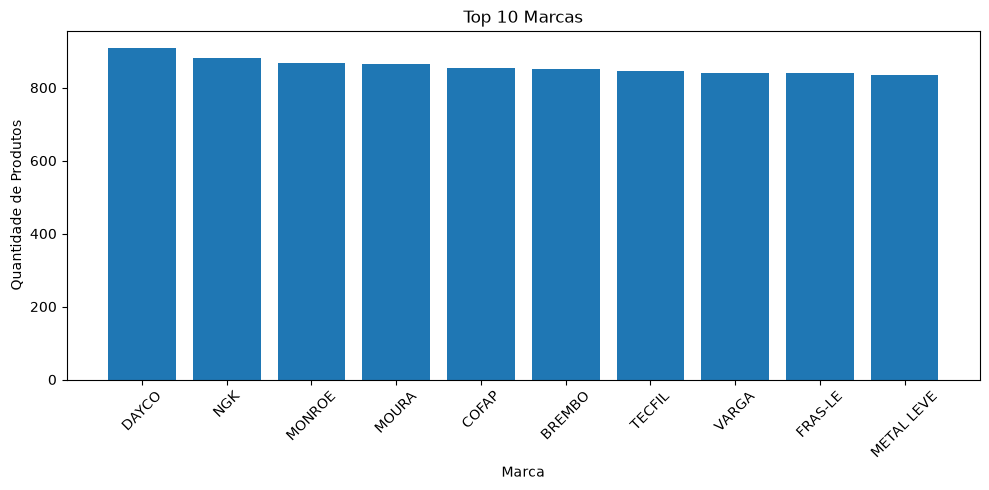

In [29]:
query = """
SELECT
    BRAND_NAME,
    COUNT(*) AS TOTAL
FROM parts
GROUP BY BRAND_NAME
ORDER BY TOTAL DESC
LIMIT 10;
"""

df = pd.read_sql(query, conn)

plt.figure(figsize=(10,5))

plt.bar(df["brand_name"], df["TOTAL"])

plt.title("Top 10 Marcas")

plt.xlabel("Marca")

plt.ylabel("Quantidade de Produtos")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Gráfico 2 — Distribuição dos Preços

Este histograma apresenta como os preços estão distribuídos ao longo do catálogo, permitindo observar a concentração dos produtos em determinadas faixas de preço.

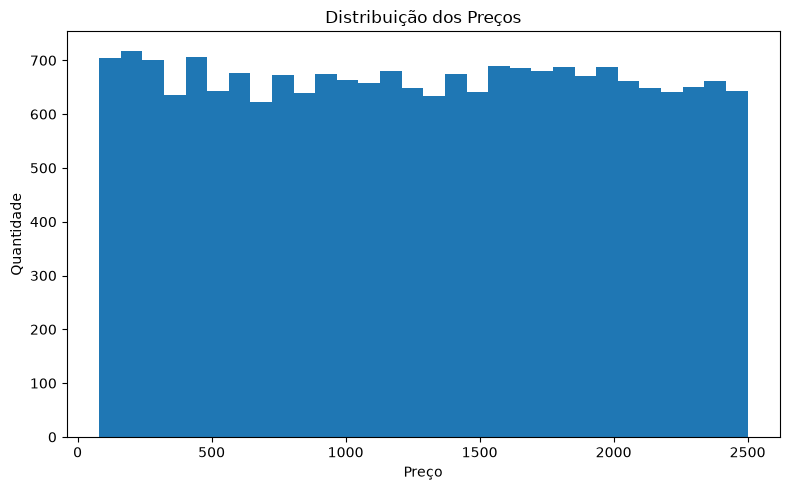

In [30]:
query = """
SELECT PRICE
FROM parts
WHERE PRICE IS NOT NULL;
"""

df = pd.read_sql(query, conn)

plt.figure(figsize=(8,5))

plt.hist(df["price"], bins=30)

plt.title("Distribuição dos Preços")

plt.xlabel("Preço")

plt.ylabel("Quantidade")

plt.tight_layout()

plt.show()

## Gráfico 3 — Preço Médio por Categoria

O gráfico compara o preço médio das categorias de produtos, destacando aquelas que possuem maior valor médio.

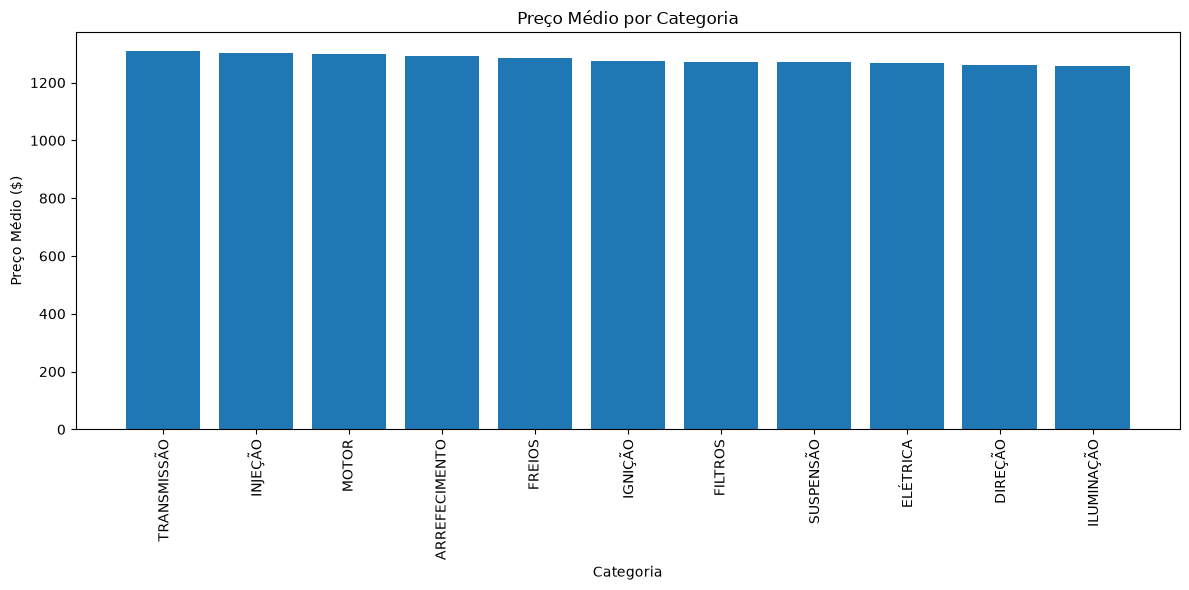

In [40]:
query = """
SELECT
    CATEGORY,
    AVG(PRICE) AS PRECO_MEDIO
FROM parts
GROUP BY CATEGORY
ORDER BY PRECO_MEDIO DESC;
"""

df = pd.read_sql(query, conn)

plt.figure(figsize=(12,6))

plt.bar(df["category"], df["PRECO_MEDIO"])

plt.title("Preço Médio por Categoria")

plt.xlabel("Categoria")

plt.ylabel("Preço Médio ($)")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

# Conclusão

A análise exploratória permitiu compreender aspectos importantes do conjunto de dados coletado pelo pipeline ETL.

Entre os principais resultados obtidos destacam-se:

- Quantificação do catálogo de produtos;
- Identificação das marcas e categorias mais representativas;
- Avaliação da distribuição dos preços;
- Análise da disponibilidade em estoque;
- Comparação do preço médio entre categorias.

A utilização de consultas SQL juntamente com Matplotlib permitiu extrair informações relevantes e apresentar os resultados de forma clara e organizada.